# Wound Healing Simulation

Blueprint-aligned notebook: every subsection includes a short explanation and matching code.


In [34]:
# Global setup (inline output only)
import numpy as np
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
import matplotlib.pyplot as plt
from matplotlib import animation
from scipy import ndimage

try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except Exception:
    pass

plt.ioff()
np.random.seed(42)
rng = np.random.default_rng(42)


try:
    import imageio.v2 as imageio
    HAS_IMAGEIO = True
except Exception:
    HAS_IMAGEIO = False

## 1. Introduction & Theory

### 1.1 Wound Healing Simulation Overview
Model: wound mask + healer walkers + infection process + coupled dynamics.

### 1.2 Mathematical Framework (LaTeX)
- Random walk fundamentals
- Persistent vs classic random walk
- Healing mechanism & counter system
- Infection dynamics overview

$$
\text{healed}(x) \Leftrightarrow \text{visits}(x) \ge \text{threshold}(x)
$$

$$
\mathbf{h}_t = \alpha \mathbf{h}_{t-1} + (1-\alpha)\boldsymbol\eta_t
$$

$$
\text{threshold}(d)=\text{min}_{\text{thr}} + (\text{max}_{\text{thr}}-\text{min}_{\text{thr}})\frac{d}{d_{\max}}
$$


## 2. Wound Geometry

### 2.1 Theory: Wound shape generation and boundaries
- Parametric boundary with harmonics
- Rasterization to binary mask
- BFS/EDT distance computation

$$
r(\theta)=r_0+\sum_k[a_k\cos(k\theta)+b_k\sin(k\theta)] + \epsilon(\theta)
$$


### 2.2 Step 1: Noisy boundary generation

In [35]:
def boundary_noise_1d(n=360, scale=8, seed=42):
    """1D smoothed noise for radial boundary perturbation."""
    np.random.seed(seed)
    z = np.random.randn(n)
    return ndimage.gaussian_filter(z, sigma=scale)


def _fade(t):
    return 6 * t**5 - 15 * t**4 + 10 * t**3


def _lerp(a, b, t):
    return a + t * (b - a)


def _perlin_gradient(ix, iy, seed=0):
    n = (ix * 1836311903) ^ (iy * 2971215073) ^ seed
    n = n.astype(np.uint32)
    n ^= (n >> np.uint32(13))
    n *= np.uint32(1274126177)
    n ^= (n >> np.uint32(16))
    angle = (n.astype(np.float64) / np.float64(2**32 - 1)) * (2.0 * np.pi)
    return np.cos(angle), np.sin(angle)


def perlin2d(shape, frequency=4.0, octaves=4, seed=0):
    """Standard 2D Perlin FBM map in [0,1]."""
    h, w = shape
    yy, xx = np.mgrid[0:h, 0:w]
    x = (xx / max(w - 1, 1)) * frequency
    y = (yy / max(h - 1, 1)) * frequency

    total = np.zeros((h, w), dtype=float)
    norm = 0.0
    amp = 1.0
    freq = 1.0

    for oc in range(octaves):
        xf = x * freq
        yf = y * freq

        x0 = np.floor(xf).astype(np.int64)
        y0 = np.floor(yf).astype(np.int64)
        x1 = x0 + 1
        y1 = y0 + 1

        sx = _fade(xf - x0)
        sy = _fade(yf - y0)

        g00x, g00y = _perlin_gradient(x0, y0, seed + oc * 101)
        g10x, g10y = _perlin_gradient(x1, y0, seed + oc * 101)
        g01x, g01y = _perlin_gradient(x0, y1, seed + oc * 101)
        g11x, g11y = _perlin_gradient(x1, y1, seed + oc * 101)

        dx0 = xf - x0
        dy0 = yf - y0
        dx1 = xf - x1
        dy1 = yf - y1

        n00 = g00x * dx0 + g00y * dy0
        n10 = g10x * dx1 + g10y * dy0
        n01 = g01x * dx0 + g01y * dy1
        n11 = g11x * dx1 + g11y * dy1

        nx0 = _lerp(n00, n10, sx)
        nx1 = _lerp(n01, n11, sx)
        nxy = _lerp(nx0, nx1, sy)

        total += amp * nxy
        norm += amp
        freq *= 2.0
        amp *= 0.5

    total /= (norm + 1e-9)
    total -= total.min()
    total /= (total.max() + 1e-9)
    return total


def generate_noisy_boundary(center, r_min=40, r_max=80, n_harmonics=5):
    theta = np.linspace(0, 2*np.pi, 360, endpoint=False)
    r0 = 0.5 * (r_min + r_max)
    r = np.full_like(theta, r0, dtype=float)
    for k in range(1, n_harmonics + 1):
        a, b = rng.uniform(-0.2, 0.2), rng.uniform(-0.2, 0.2)
        r += 0.25 * (r_max - r_min) * (a*np.cos(k*theta) + b*np.sin(k*theta))
    noise = boundary_noise_1d(360, scale=8, seed=42)
    noise = (noise - noise.min()) / (noise.max() - noise.min() + 1e-9)
    r += 0.12 * (r_max - r_min) * noise
    r = np.clip(r, r_min, r_max)
    x = center[0] + r*np.cos(theta)
    y = center[1] + r*np.sin(theta)
    return np.column_stack([x, y])

IMG_SIZE = 256
CENTER = (IMG_SIZE//2, IMG_SIZE//2)
boundary_pts = generate_noisy_boundary(CENTER)

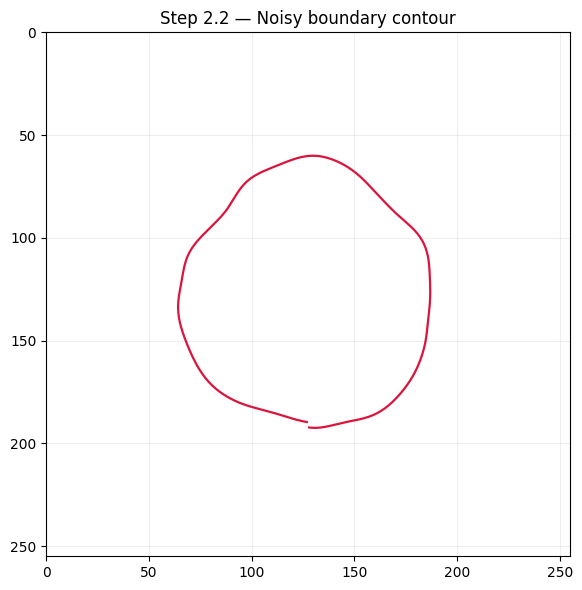

In [36]:
# Viz: Step 2.2 noisy boundary (parametric contour)
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(boundary_pts[:, 1], boundary_pts[:, 0], color='crimson', lw=1.6)
ax.set_title('Step 2.2 — Noisy boundary contour')
ax.set_xlim(0, IMG_SIZE-1)
ax.set_ylim(0, IMG_SIZE-1)
ax.set_aspect('equal')
ax.invert_yaxis()
ax.grid(alpha=0.2)
plt.tight_layout(); plt.show()

### 2.3 Step 2: Rasterization to binary mask

In [37]:
def rasterize_boundary(boundary_pts, img_size=256):
    pts = np.clip(np.rint(boundary_pts).astype(int), 0, img_size-1)
    mask = np.zeros((img_size, img_size), dtype=bool)
    for i in range(len(pts)):
        p0, p1 = pts[i], pts[(i+1) % len(pts)]
        n = int(max(abs(p1[0]-p0[0]), abs(p1[1]-p0[1]))) + 1
        rr = np.linspace(p0[0], p1[0], n).round().astype(int)
        cc = np.linspace(p0[1], p1[1], n).round().astype(int)
        mask[rr, cc] = True
    return ndimage.binary_fill_holes(mask)

wound_mask = rasterize_boundary(boundary_pts, IMG_SIZE)

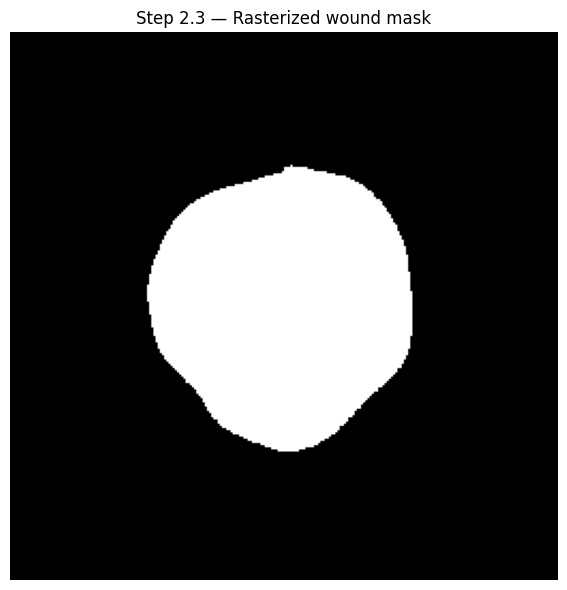

In [38]:
# Viz: Step 2.3 rasterized binary mask
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(wound_mask, origin='lower', cmap='gray')
ax.set_title('Step 2.3 — Rasterized wound mask')
ax.axis('off')
plt.tight_layout(); plt.show()

### 2.4 Step 3: Boundary ring extraction

In [39]:
def get_boundary_ring(mask, width=1):
    eroded = ndimage.binary_erosion(mask, iterations=width)
    return mask & ~eroded

boundary_ring = get_boundary_ring(wound_mask, width=1)

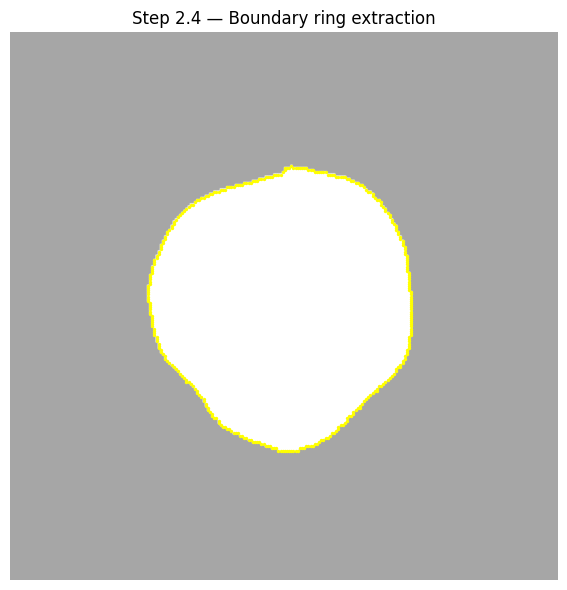

In [40]:
# Viz: Step 2.4 boundary ring overlay
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(wound_mask, origin='lower', cmap='gray', alpha=0.35)
rr, cc = np.where(boundary_ring)
ax.scatter(cc, rr, s=2, c='yellow')
ax.set_title('Step 2.4 — Boundary ring extraction')
ax.axis('off')
plt.tight_layout(); plt.show()

### 2.5 Step 4: BFS distance map

In [41]:
def compute_distance_map(mask):
    dist = ndimage.distance_transform_edt(mask)
    dist[~mask] = np.inf
    return dist

dist_to_boundary = compute_distance_map(wound_mask)

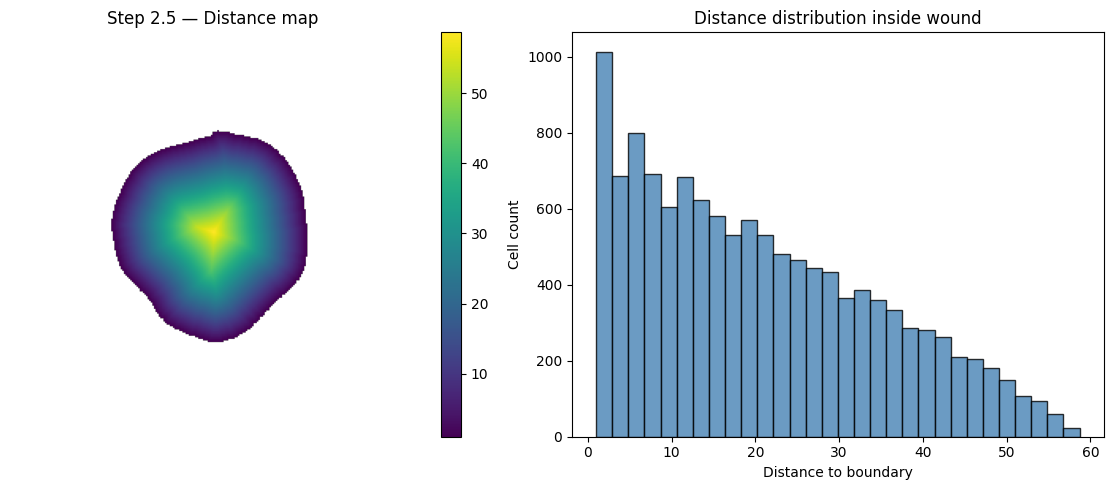

In [42]:
# Viz: Step 2.5 distance map + histogram
vals = dist_to_boundary[wound_mask]
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

dv = dist_to_boundary.copy(); dv[~wound_mask] = np.nan
im = ax[0].imshow(dv, origin='lower', cmap='viridis')
ax[0].set_title('Step 2.5 — Distance map')
ax[0].axis('off')
plt.colorbar(im, ax=ax[0], fraction=0.046)

ax[1].hist(vals, bins=30, color='steelblue', edgecolor='black', alpha=0.8)
ax[1].set_title('Distance distribution inside wound')
ax[1].set_xlabel('Distance to boundary')
ax[1].set_ylabel('Cell count')
plt.tight_layout(); plt.show()

### 2.6 Step 4b: Wound texture (Perlin noise)

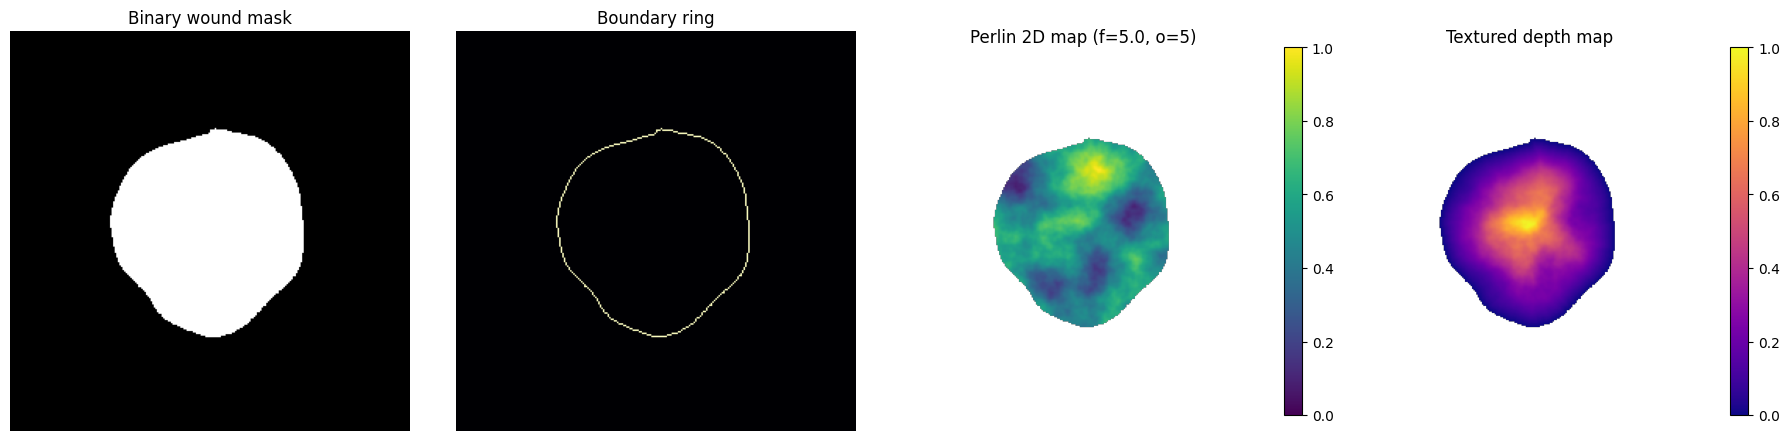

In [43]:
perlin_frequency = 5.0
perlin_octaves = 5
perlin_strength = 0.55

# Keep a frozen base depth map (without texture) for diagnostics/ablation
if 'dist_to_boundary_base' not in globals():
    dist_to_boundary_base = dist_to_boundary.copy()

# True 2D Perlin map (as in original notebook)
perlin_map = perlin2d(wound_mask.shape, frequency=perlin_frequency, octaves=perlin_octaves, seed=41)

# Modulate normalized base depth
base_depth = dist_to_boundary_base.copy()
base_norm = np.zeros_like(base_depth, dtype=float)
vals = base_depth[wound_mask]
base_norm[wound_mask] = (vals - vals.min()) / (vals.max() - vals.min() + 1e-9)

modulation = 1.0 + perlin_strength * (2.0 * perlin_map - 1.0)
textured_depth = np.zeros_like(base_norm, dtype=float)
textured_depth[wound_mask] = base_norm[wound_mask] * modulation[wound_mask]

tv = textured_depth[wound_mask]
textured_depth[wound_mask] = (tv - tv.min()) / (tv.max() - tv.min() + 1e-9)

# Active depth map used downstream (same idea as in the original notebook)
dist_to_boundary_textured = np.full_like(dist_to_boundary_base, np.inf, dtype=float)
dist_to_boundary_textured[wound_mask] = 1.0 + 9.0 * textured_depth[wound_mask]
dist_to_boundary = dist_to_boundary_textured

fig, ax = plt.subplots(1, 4, figsize=(18, 4.5))

ax[0].imshow(wound_mask, origin='lower', cmap='gray')
ax[0].set_title('Binary wound mask')
ax[0].axis('off')

ring_viz = np.zeros_like(wound_mask, dtype=float)
ring_viz[boundary_ring] = 1.0
ax[1].imshow(ring_viz, origin='lower', cmap='magma')
ax[1].set_title('Boundary ring')
ax[1].axis('off')

pp = perlin_map.copy(); pp[~wound_mask] = np.nan
im2 = ax[2].imshow(pp, origin='lower', cmap='viridis', vmin=0, vmax=1)
ax[2].set_title(f'Perlin 2D map (f={perlin_frequency}, o={perlin_octaves})')
ax[2].axis('off')
plt.colorbar(im2, ax=ax[2], fraction=0.046)

td = textured_depth.copy(); td[~wound_mask] = np.nan
im3 = ax[3].imshow(td, origin='lower', cmap='plasma', vmin=0, vmax=1)
ax[3].set_title('Textured depth map')
ax[3].axis('off')
plt.colorbar(im3, ax=ax[3], fraction=0.046)

plt.tight_layout(); plt.show()

## 3. Random Walk Framework & Healing Mechanism

### 3.0 Theory: Healing Counter & Depth-Dependent Thresholds
$$
\text{threshold}(d)=\text{min\_thr}+(\text{max\_thr}-\text{min\_thr})\frac{d}{d_{\max}}
$$
- Visit counter mechanism
- Threshold scaling with depth
- Color mapping: visits remaining → wound intensity
- Neighbor healing effects


### 3.1 Theory: CRW vs PRW with LaTeX formulas
- Classic Random Walk: uniform neighbor selection
- Persistent Random Walk: $h_t = \alpha h_{t-1} + (1-\alpha)\eta_t$
- Drift persistence coefficient $\alpha$
- Comparison: displacement vs tortuosity


In [44]:
OFFSETS8 = np.array([[-1,-1],[-1,0],[-1,1],[0,-1],[0,1],[1,-1],[1,0],[1,1]])

def valid_neighbors(pos, shape, allowed_mask=None):
    cand = pos[None, :] + OFFSETS8
    m = (cand[:,0] >= 0) & (cand[:,0] < shape[0]) & (cand[:,1] >= 0) & (cand[:,1] < shape[1])
    cand = cand[m]
    if allowed_mask is not None:
        cand = cand[allowed_mask[cand[:,0], cand[:,1]]]
    return cand

def simulate_crw(start, n_steps, allowed_mask):
    p = np.array(start, dtype=int)
    path = [p.copy()]
    for _ in range(n_steps):
        cand = valid_neighbors(p, allowed_mask.shape, allowed_mask)
        if len(cand):
            p = cand[rng.integers(len(cand))]
        path.append(p.copy())
    return np.array(path)

def simulate_prw(start, n_steps, allowed_mask, alpha=0.7):
    p = np.array(start, dtype=int)
    h = np.zeros(2)
    path = [p.copy()]
    for _ in range(n_steps):
        cand = valid_neighbors(p, allowed_mask.shape, allowed_mask)
        if len(cand):
            dirs = cand - p
            dirs_n = dirs / (np.linalg.norm(dirs, axis=1, keepdims=True) + 1e-9)
            eta = rng.normal(size=2)
            eta = eta / (np.linalg.norm(eta) + 1e-9)
            h = alpha * h + (1 - alpha) * eta
            scores = dirs_n @ h + 0.05 * rng.normal(size=len(cand))
            p = cand[np.argmax(scores)]
        path.append(p.copy())
    return np.array(path)

### 3.2 Demo 1: Path comparison (CRW vs PRW)
Static side-by-side comparison with displacement and tortuosity metrics.


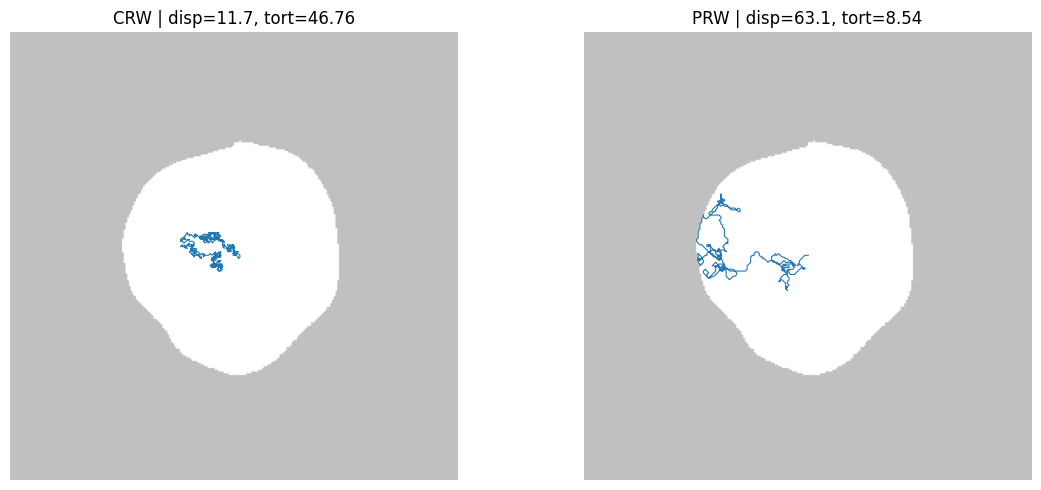

In [45]:
start = np.array([IMG_SIZE//2, IMG_SIZE//2])
crw = simulate_crw(start, 450, wound_mask)
prw = simulate_prw(start, 450, wound_mask, alpha=0.75)

def metrics(path):
    disp = np.linalg.norm(path[-1] - path[0])
    length = np.linalg.norm(np.diff(path, axis=0), axis=1).sum()
    tort = length / (disp + 1e-9)
    return disp, tort

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
for a, path, name in [(ax[0], crw, 'CRW'), (ax[1], prw, 'PRW')]:
    a.imshow(wound_mask, origin='lower', cmap='gray', alpha=0.25)
    a.plot(path[:,1], path[:,0], lw=0.8)
    d, t = metrics(path)
    a.set_title(f'{name} | disp={d:.1f}, tort={t:.2f}')
    a.axis('off')
plt.tight_layout(); plt.show()

# Optional export
# fig.savefig('crw_vs_prw_static.png', dpi=160, bbox_inches='tight')

### 3.3 Demo 2: Drift sector visualization
Animated PRW walker on clean grid with highlighted sector and heading.


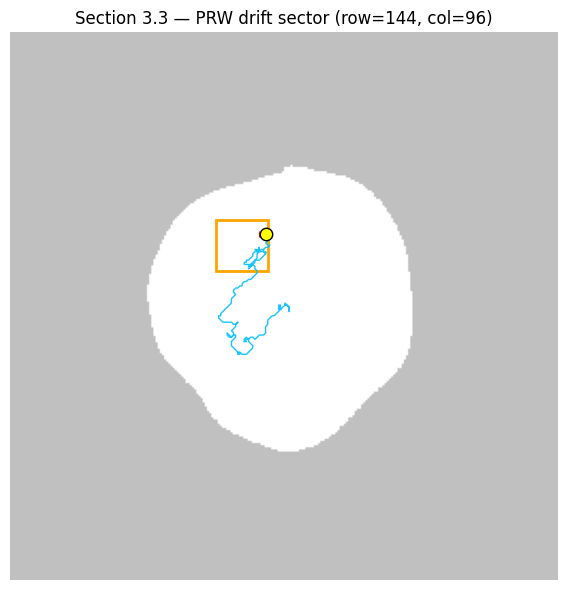

In [46]:
def sector_box(pos, sector_size=24):
    r0 = (pos[0] // sector_size) * sector_size
    c0 = (pos[1] // sector_size) * sector_size
    return r0, c0, sector_size

# PRW sector visualization (clean-grid demo)
start_demo = np.array([IMG_SIZE//2, IMG_SIZE//2])
path_demo = simulate_prw(start_demo, 180, wound_mask, alpha=0.75)
current = path_demo[-1]
prev = path_demo[-2] if len(path_demo) > 1 else current
heading = current - prev

r0, c0, ss = sector_box(current, sector_size=24)

fig, ax = plt.subplots(figsize=(6,6))
ax.imshow(wound_mask, origin='lower', cmap='gray', alpha=0.25)
ax.plot(path_demo[:,1], path_demo[:,0], color='deepskyblue', lw=1.0, alpha=0.9)
ax.scatter(current[1], current[0], c='yellow', s=80, edgecolors='black', zorder=5)
ax.add_patch(plt.Rectangle((c0, r0), ss, ss, fill=False, edgecolor='orange', linewidth=2))
ax.arrow(current[1], current[0], heading[1], heading[0], color='red', head_width=2.5, length_includes_head=True)
ax.set_title(f'Section 3.3 — PRW drift sector (row={r0}, col={c0})')
ax.axis('off')
plt.tight_layout(); plt.show()

### 3.4 Step 5: Healer agent spawn points
K-means-style center update on boundary points.


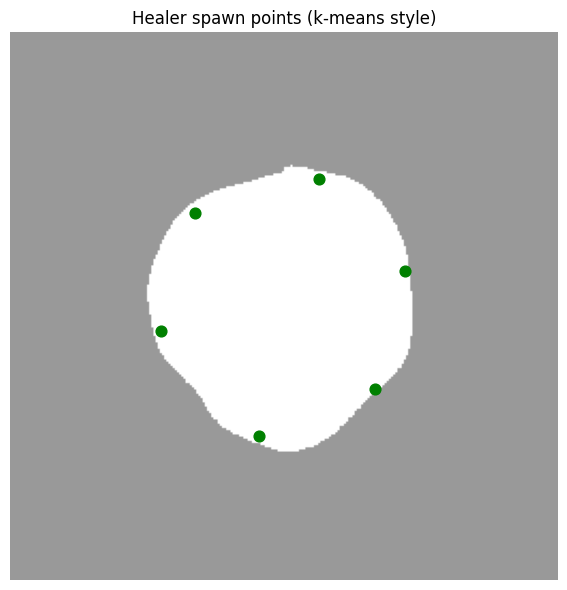

In [47]:
def kmeans_simple(points, k=6, n_iter=20):
    idx = rng.choice(len(points), size=k, replace=False)
    centers = points[idx].astype(float)
    for _ in range(n_iter):
        d2 = ((points[:,None,:]-centers[None,:,:])**2).sum(axis=2)
        labels = d2.argmin(axis=1)
        new_centers = centers.copy()
        for j in range(k):
            pj = points[labels==j]
            if len(pj):
                new_centers[j] = pj.mean(axis=0)
        centers = new_centers
    return np.rint(centers).astype(int)

boundary_points = np.argwhere(boundary_ring)
start_cells_rc = kmeans_simple(boundary_points, k=6, n_iter=25)

fig, ax = plt.subplots(figsize=(6,6))
ax.imshow(wound_mask, origin='lower', cmap='gray', alpha=0.4)
ax.scatter(start_cells_rc[:,1], start_cells_rc[:,0], c='green', s=60)
ax.set_title('Healer spawn points (k-means style)')
ax.axis('off')
plt.tight_layout(); plt.show()

### 3.5 Depth-dependent healing thresholds
Threshold map from boundary (min) to deepest region (max).


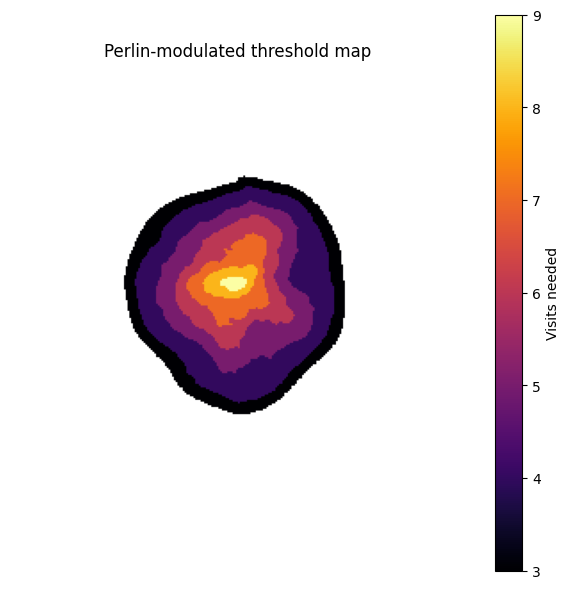

In [48]:
heal_threshold = 3
threshold_map = np.where(
    wound_mask,
    np.round(heal_threshold + (heal_threshold*3 - heal_threshold) * np.clip(textured_depth, 0.0, 1.0)).astype(np.int32),
    0,
)

tp = threshold_map.astype(float)
tp[~wound_mask] = np.nan
fig, ax = plt.subplots(figsize=(6,6))
im = ax.imshow(tp, origin='lower', cmap='inferno')
ax.set_title('Perlin-modulated threshold map')
ax.axis('off')
plt.colorbar(im, ax=ax, label='Visits needed')
plt.tight_layout(); plt.show()

### 3.6 Simulation and visualization
No-drift healing simulation and optional GIF export.


In [49]:
def run_nodrift_healing(mask, start_cells_rc, threshold_map, n_steps=300, snapshot_every=20, walkers_per_spawn=2):
    walkers = np.repeat(start_cells_rc, walkers_per_spawn, axis=0).astype(int)
    visits = np.zeros(mask.shape, dtype=np.int32)
    healed = np.zeros(mask.shape, dtype=bool)
    snaps = []
    for step in range(n_steps):
        for i in range(len(walkers)):
            cand = valid_neighbors(walkers[i], mask.shape, mask)
            if len(cand):
                explore = 1.0 / (1.0 + visits[cand[:,0], cand[:,1]])
                walkers[i] = cand[np.argmax(explore + 0.2*rng.random(len(cand)))]
                r,c = walkers[i]
                visits[r,c] += 1
                if visits[r,c] >= threshold_map[r,c]:
                    healed[r,c] = True
        if step % snapshot_every == 0 or step == n_steps-1:
            snaps.append((step, visits.copy(), healed.copy(), walkers.copy()))
    return snaps, visits, healed

snapshots_nd, visit_counts_nd, healed_nd = run_nodrift_healing(
    wound_mask, start_cells_rc, threshold_map, n_steps=260, snapshot_every=20, walkers_per_spawn=2
)
print(f'No-drift healed: {healed_nd.sum()} / {wound_mask.sum()} ({100*healed_nd.sum()/wound_mask.sum():.1f}%)')


No-drift healed: 0 / 12428 (0.0%)


## 5. Infection Dynamics

### 5.1 Theory: Infection spread, counter system, death mechanics (LaTeX)
- States: sleeping, active, dead
- Spread probability: $p(\text{spread} \mid \text{neighbor}) = p_{\text{spread}}$
- Counter evolution: $\text{counter}_t = \text{counter}_{t-1} + 1$ with prob $p_{\text{regrow}}$
- Death threshold: counter $\ge$ death_threshold
- Healing blocking by infection


### 5.2 Step 6: Infection point selection
Depth-weighted sampling of initial infection seeds.


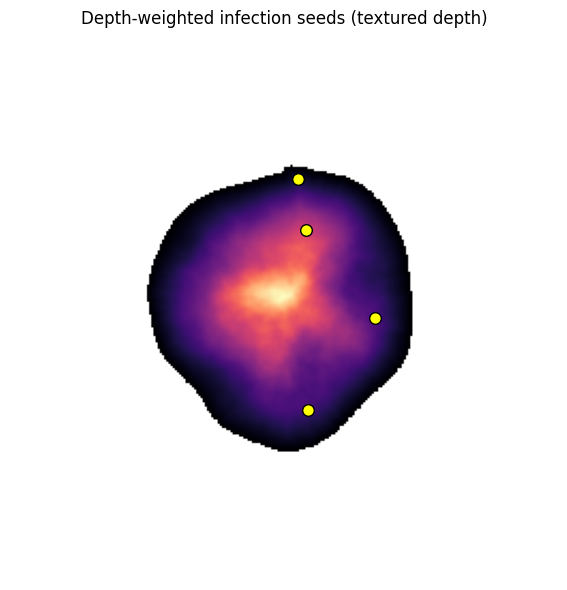

In [50]:
def select_infection_seeds(mask, dist_map, n_seeds=4, beta=1.3):
    cells = np.argwhere(mask)
    depths = dist_map[cells[:,0], cells[:,1]]
    w = (depths / (depths.max() + 1e-9)) ** beta
    w = w / (w.sum() + 1e-12)
    idx = rng.choice(len(cells), size=min(n_seeds, len(cells)), replace=False, p=w)
    return cells[idx]

infection_seeds = select_infection_seeds(wound_mask, dist_to_boundary, n_seeds=4)

fig, ax = plt.subplots(figsize=(6,6))
dv = dist_to_boundary.copy(); dv[~wound_mask] = np.nan
ax.imshow(dv, origin='lower', cmap='magma')
ax.scatter(infection_seeds[:,1], infection_seeds[:,0], c='yellow', s=70, edgecolors='black')
ax.set_title('Depth-weighted infection seeds (textured depth)')
ax.axis('off')
plt.tight_layout(); plt.show()

### 5.3 Step 6b: Infection-only progression
Infection simulation without healing walkers.


In [51]:
def run_infection_only(mask, seeds, n_steps=220, p_spread=0.06, p_regrow=0.08, death_threshold=12, snapshot_every=20):
    infected = np.zeros(mask.shape, dtype=bool)
    dead = np.zeros(mask.shape, dtype=bool)
    counter = np.zeros(mask.shape, dtype=np.int32)
    for r,c in seeds:
        infected[r,c] = True
        counter[r,c] = 1
    snaps = []
    for t in range(n_steps):
        new_inf = np.zeros_like(infected)
        for r,c in np.argwhere(infected):
            # Dead infected cells remain infectious and may continue spreading.
            if rng.random() < p_regrow:
                counter[r,c] += 1
            if counter[r,c] >= death_threshold:
                dead[r,c] = True
            for dr,dc in OFFSETS8:
                nr,nc = r+dr, c+dc
                if 0 <= nr < mask.shape[0] and 0 <= nc < mask.shape[1] and mask[nr,nc] and (not infected[nr,nc]):
                    if rng.random() < p_spread:
                        new_inf[nr,nc] = True
        infected |= new_inf
        if t % snapshot_every == 0 or t == n_steps-1:
            snaps.append((t, infected.copy(), dead.copy(), counter.copy()))
    return snaps, infected, dead, counter

snapshots_inf, infected_only, dead_only, counter_only = run_infection_only(wound_mask, infection_seeds)
print(f'Infection-only dead: {dead_only.sum()} | infected: {infected_only.sum()}')


Infection-only dead: 4153 | infected: 11685


### 5.4 Step 6c: Sector grid for infection scoring
Create sector IDs and infection-density per sector.


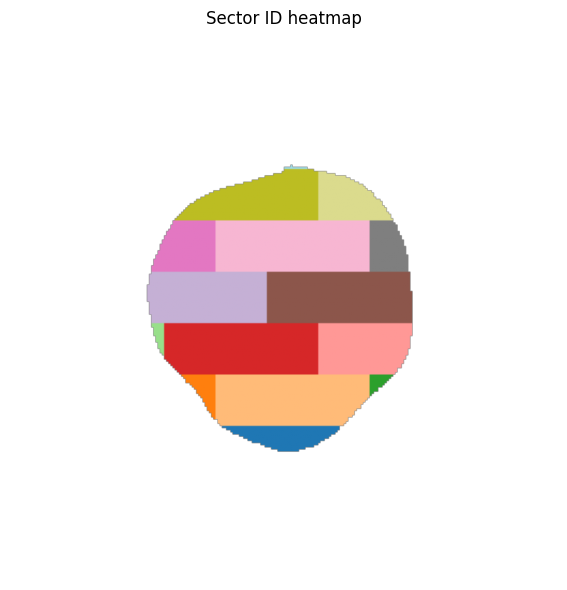

In [52]:
def build_sector_ids(shape, sector_size=24):
    rr, cc = np.indices(shape)
    sr = rr // sector_size
    sc = cc // sector_size
    return sr, sc, sr * (shape[1] // sector_size + 1) + sc

sector_r, sector_c, sector_id = build_sector_ids(wound_mask.shape, sector_size=24)

fig, ax = plt.subplots(figsize=(6,6))
sid = sector_id.astype(float)
sid[~wound_mask] = np.nan
im = ax.imshow(sid, origin='lower', cmap='tab20')
ax.set_title('Sector ID heatmap')
ax.axis('off')
plt.tight_layout(); plt.show()

## 6. Walker Death & Cell Isolation Mechanics

### 6.1 Theory: Walker trapping and gradual cell necrosis (LaTeX)
- Problem 1: Trapped walker → removal when no valid neighbors
- Problem 2: Isolated healed cells without path to boundary → gradual death
- Boundary reachability via connected components
- Isolation counter: $\text{isolation\_counter}_t = \text{counter}_{t-1} + 1$
- Cell death at threshold: $\text{isolation\_counter} \ge \text{death\_threshold}$


### 6.2 Helper functions

In [53]:
def compute_boundary_reachability(healed_map, dead_map, wound_mask):
    traversable = ~dead_map
    labeled, _ = ndimage.label(traversable)
    boundary_labels = set(labeled[0,:]) | set(labeled[-1,:]) | set(labeled[:,0]) | set(labeled[:,-1])
    boundary_labels.discard(0)
    has_path = np.zeros_like(traversable, dtype=bool)
    for lab in boundary_labels:
        has_path |= (labeled == lab)
    return has_path

def apply_isolation_necrosis(healed_map, has_path, isolation_counter, death_threshold=10):
    isolated = healed_map & ~has_path
    isolation_counter[isolated] += 1
    newly_dead = isolated & (isolation_counter >= death_threshold)
    healed_map = healed_map & ~newly_dead
    isolation_counter[~isolated] = 0
    return healed_map, isolation_counter

def remove_trapped_walkers(walkers, active_mask):
    alive = []
    for i, p in enumerate(walkers):
        cand = valid_neighbors(p, active_mask.shape)
        if len(cand) and np.any(active_mask[cand[:,0], cand[:,1]]):
            alive.append(i)
    if alive:
        return walkers[alive], np.array(alive)
    return np.empty((0,2), dtype=int), np.array([], dtype=int)

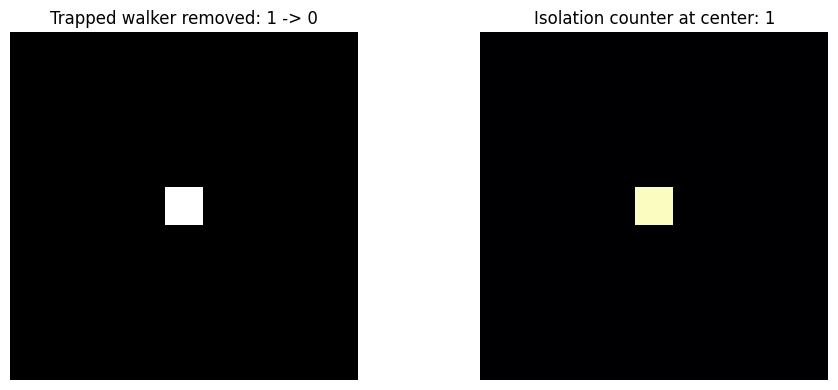

In [54]:
# Viz: Section 6 sanity checks (trapping + isolation)
# Trapped walker example
small = np.zeros((9, 9), dtype=bool)
small[4, 4] = True
w_small = np.array([[4, 4]])
after, _ = remove_trapped_walkers(w_small, small)

# Isolation example
healed_s = np.zeros((9, 9), dtype=bool); healed_s[4, 4] = True
dead_s = np.ones((9, 9), dtype=bool); dead_s[4, 4] = False
has_path_s = compute_boundary_reachability(healed_s, dead_s, np.ones_like(dead_s, dtype=bool))
iso_counter_s = np.zeros((9, 9), dtype=np.int32)
_, iso_counter_s = apply_isolation_necrosis(healed_s.copy(), has_path_s, iso_counter_s, death_threshold=3)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(small, origin='lower', cmap='gray')
ax[0].set_title(f'Trapped walker removed: {len(w_small)} -> {len(after)}')
ax[0].axis('off')

viz = np.zeros((9,9), dtype=float)
viz[healed_s] = 0.7
viz[dead_s] = 0.2
ax[1].imshow(viz, origin='lower', cmap='magma')
ax[1].set_title(f'Isolation counter at center: {iso_counter_s[4,4]}')
ax[1].axis('off')
plt.tight_layout(); plt.show()

### 6.3 Integration into main loop
Walker death check after movement, reachability recomputation every N steps, isolation counter tracking.


## 7. Main Simulation: Healing + Infection Dynamics

### 7.1 Theory: Persistent RW with drift, sector scoring, neighbor healing (LaTeX)
$$
\text{score}_{\text{sector}} = w_{\text{inf}}\cdot\text{inf\_density} + w_{\text{depth}}\cdot\text{depth}
$$


### 7.2 Implementation: run_walker_healing_with_infection()

In [55]:
def run_walker_healing_with_infection(
    wound_mask,
    start_cells_rc,
    dist_to_boundary,
    depth_map,
    n_steps=320,
    snapshot_every=20,
    min_thr=2,
    max_thr=6,
    walkers_per_spawn=2,
    alpha=0.75,
    p_spread=0.03,
    p_regrow=0.08,
    death_threshold=20,
    isolation_threshold=10,
):
    walkers = np.repeat(start_cells_rc, walkers_per_spawn, axis=0).astype(int)
    heading = np.zeros((len(walkers), 2), dtype=float)

    visits = np.zeros(wound_mask.shape, dtype=np.int32)
    healed = np.zeros(wound_mask.shape, dtype=bool)
    infected = np.zeros(wound_mask.shape, dtype=bool)
    dead = np.zeros(wound_mask.shape, dtype=bool)
    counter = np.zeros(wound_mask.shape, dtype=np.int32)
    isolation_counter = np.zeros(wound_mask.shape, dtype=np.int32)

    threshold_map = np.where(
        wound_mask,
        np.round(min_thr + (max_thr - min_thr) * np.clip(depth_map, 0.0, 1.0)).astype(np.int32),
        0,
    )

    # Infection seeds follow the same textured depth field as healing thresholds.
    seeds = select_infection_seeds(wound_mask, dist_to_boundary, n_seeds=4)
    for r,c in seeds:
        infected[r,c] = True
        counter[r,c] = 1

    snapshots = []
    walker_deaths_log = []

    for t in range(n_steps):
        for i in range(len(walkers)):
            p = walkers[i]
            cand = valid_neighbors(p, wound_mask.shape, wound_mask)
            if not len(cand):
                continue
            dirs = cand - p
            dirs_n = dirs / (np.linalg.norm(dirs, axis=1, keepdims=True) + 1e-9)
            eta = rng.normal(size=2); eta /= (np.linalg.norm(eta)+1e-9)
            heading[i] = alpha * heading[i] + (1-alpha) * eta
            scores = dirs_n @ heading[i] + 0.3 / (1 + visits[cand[:,0], cand[:,1]])
            walkers[i] = cand[np.argmax(scores)]

            r,c = walkers[i]
            visits[r,c] += 1
            if visits[r,c] >= threshold_map[r,c] and not infected[r,c] and not dead[r,c]:
                healed[r,c] = True

        # walker death
        active_mask = (wound_mask | healed | infected) & ~dead
        before = len(walkers)
        walkers, alive_idx = remove_trapped_walkers(walkers, active_mask)
        heading = heading[alive_idx] if len(alive_idx) else np.empty((0,2))
        if len(walkers) < before:
            walker_deaths_log.append((t, before-len(walkers)))

        # infection
        new_inf = np.zeros_like(infected)
        for r,c in np.argwhere(infected):
            # Dead infected cells can continue infecting neighbors.
            if rng.random() < p_regrow:
                counter[r,c] += 1
            if counter[r,c] >= death_threshold:
                dead[r,c] = True
                healed[r,c] = False
            for dr,dc in OFFSETS8:
                nr,nc = r+dr, c+dc
                if 0 <= nr < wound_mask.shape[0] and 0 <= nc < wound_mask.shape[1] and wound_mask[nr,nc]:
                    if (not infected[nr,nc]) and (not healed[nr,nc]) and rng.random() < p_spread:
                        new_inf[nr,nc] = True
        infected |= new_inf

        # isolation necrosis
        if t % 5 == 0:
            has_path = compute_boundary_reachability(healed, dead, wound_mask)
            healed, isolation_counter = apply_isolation_necrosis(healed, has_path, isolation_counter, isolation_threshold)

        if t % snapshot_every == 0 or t == n_steps-1:
            snapshots.append((t, visits.copy(), healed.copy(), infected.copy(), dead.copy(), walkers.copy(), isolation_counter.copy()))

    return snapshots, visits, healed, infected, dead, walker_deaths_log, threshold_map

### 7.3 Demo 3: Highlighted walker in wound

In [56]:
snapshots_main, visits_main, healed_main, infected_main, dead_main, walker_deaths_main, threshold_map_main = run_walker_healing_with_infection(
    wound_mask, start_cells_rc, dist_to_boundary, textured_depth, n_steps=300, snapshot_every=20, walkers_per_spawn=3
)
print(f'Healed: {healed_main.sum()} / {wound_mask.sum()} ({100*healed_main.sum()/wound_mask.sum():.1f}%)')
print(f'Dead: {dead_main.sum()} | Infected: {infected_main.sum()} | Walker deaths: {sum(c for _,c in walker_deaths_main)}')


Healed: 533 / 12428 (4.3%)
Dead: 1133 | Infected: 9614 | Walker deaths: 0


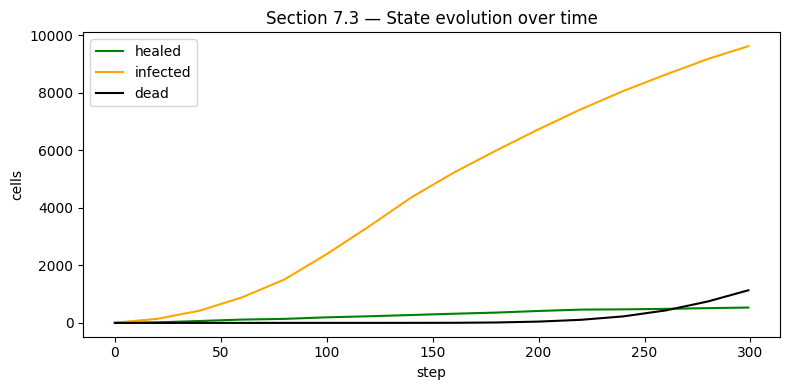

In [57]:
# Viz: Section 7.3 time-series
steps = [s[0] for s in snapshots_main]
healed_ts = [s[2].sum() for s in snapshots_main]
infected_ts = [s[3].sum() for s in snapshots_main]
dead_ts = [s[4].sum() for s in snapshots_main]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(steps, healed_ts, label='healed', color='green')
ax.plot(steps, infected_ts, label='infected', color='orange')
ax.plot(steps, dead_ts, label='dead', color='black')
ax.set_title('Section 7.3 — State evolution over time')
ax.set_xlabel('step')
ax.set_ylabel('cells')
ax.legend()
plt.tight_layout(); plt.show()


### 7.4 Full simulation visualization

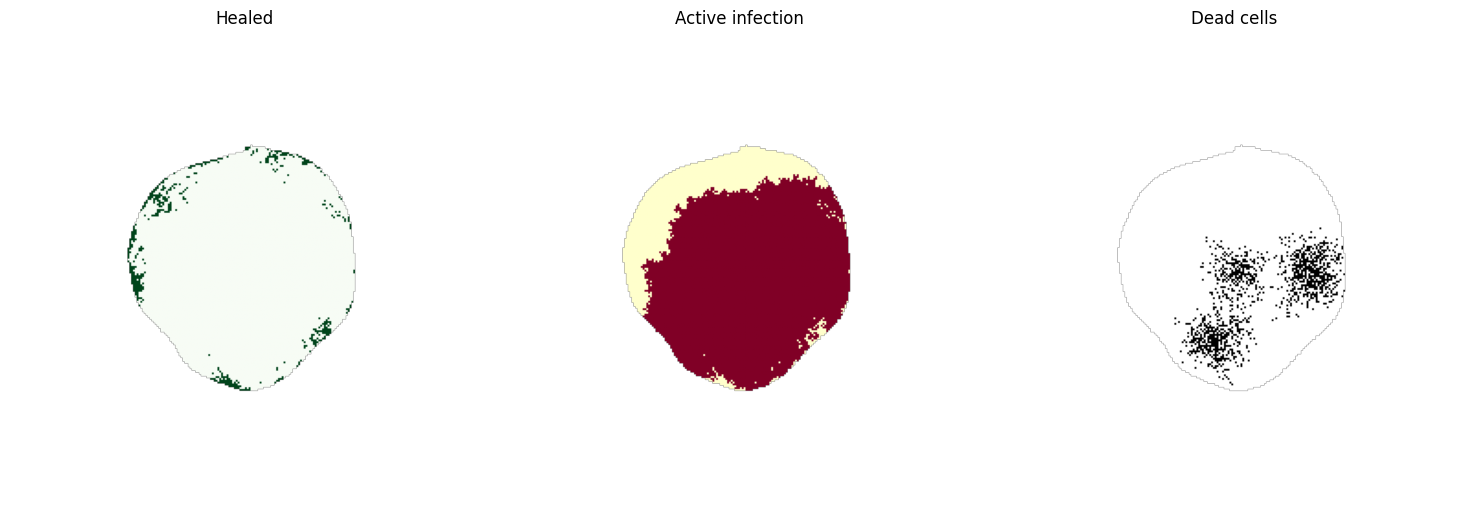

In [58]:
fig, ax = plt.subplots(1, 3, figsize=(15,5))

h = healed_main.astype(float); h[~wound_mask] = np.nan
ax[0].imshow(h, origin='lower', cmap='Greens'); ax[0].set_title('Healed'); ax[0].axis('off')

i = infected_main.astype(float); i[~wound_mask] = np.nan
ax[1].imshow(i, origin='lower', cmap='YlOrRd'); ax[1].set_title('Active infection'); ax[1].axis('off')

d = dead_main.astype(float); d[~wound_mask] = np.nan
ax[2].imshow(d, origin='lower', cmap='Greys'); ax[2].set_title('Dead cells'); ax[2].axis('off')

plt.tight_layout(); plt.show()


## 8. Comparison & Results

### 8.1 Metrics & Evaluation
- Healing efficiency
- Infection resistance
- Visit statistics
- Spatial coverage
- Walker survival


In [59]:
def summarize_metrics(mask, healed, infected, dead, visits, walker_deaths):
    wound_n = int(mask.sum())
    return {
        'healed_pct': 100*healed.sum()/wound_n,
        'infected_pct': 100*infected.sum()/wound_n,
        'dead_pct': 100*dead.sum()/wound_n,
        'mean_visits': float(visits[mask].mean()),
        'max_visits': int(visits[mask].max()),
        'walker_deaths': int(sum(c for _, c in walker_deaths)),
    }

metrics_main = summarize_metrics(wound_mask, healed_main, infected_main, dead_main, visits_main, walker_deaths_main)
metrics_main

{'healed_pct': np.float64(4.2887029288702925),
 'infected_pct': np.float64(77.3575796588349),
 'dead_pct': np.float64(9.116511103958803),
 'mean_visits': 0.4345027357579659,
 'max_visits': 11,
 'walker_deaths': 0}

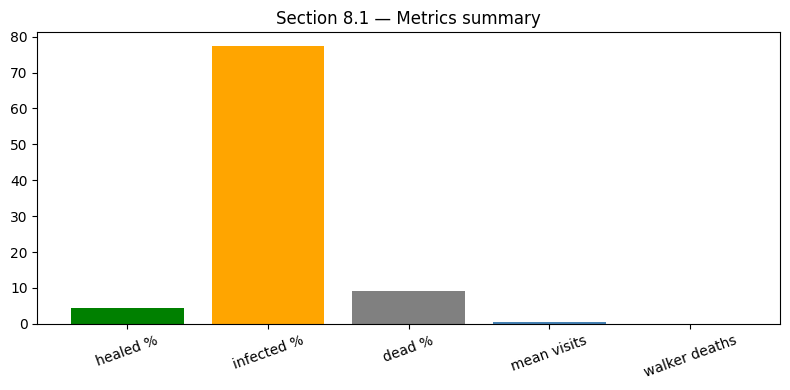

In [60]:
# Viz: Section 8.1 metrics bar chart
labels = ['healed %', 'infected %', 'dead %', 'mean visits', 'walker deaths']
vals = [
    metrics_main['healed_pct'],
    metrics_main['infected_pct'],
    metrics_main['dead_pct'],
    metrics_main['mean_visits'],
    metrics_main['walker_deaths'],
]
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(labels, vals, color=['green','orange','gray','steelblue','crimson'])
ax.set_title('Section 8.1 — Metrics summary')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

### 8.2 Comparative Analysis
PRW vs CRW vs No-Drift (using currently generated trajectories and runs).


In [61]:
# Simple comparative table
comp = {
    'CRW_disp_tort': metrics(simulate_crw(np.array([IMG_SIZE//2, IMG_SIZE//2]), 450, wound_mask)),
    'PRW_disp_tort': metrics(simulate_prw(np.array([IMG_SIZE//2, IMG_SIZE//2]), 450, wound_mask, alpha=0.75)),
    'NoDrift_healed_pct': 100*healed_nd.sum()/wound_mask.sum(),
    'Main_healed_pct': 100*healed_main.sum()/wound_mask.sum(),
}
comp

{'CRW_disp_tort': (np.float64(25.553864678361276),
  np.float64(21.451495543261412)),
 'PRW_disp_tort': (np.float64(58.412327466040935),
  np.float64(9.263917518565083)),
 'NoDrift_healed_pct': np.float64(0.0),
 'Main_healed_pct': np.float64(4.2887029288702925)}

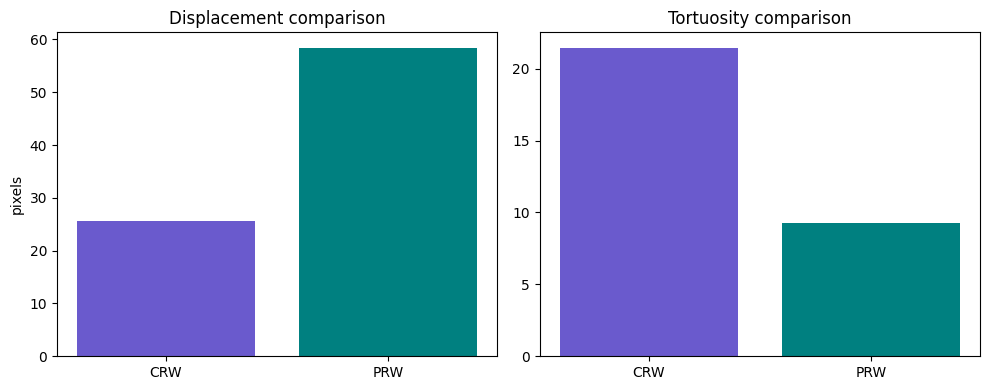

In [62]:
# Viz: Section 8.2 comparative chart
crw_disp, crw_tort = comp['CRW_disp_tort']
prw_disp, prw_tort = comp['PRW_disp_tort']

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].bar(['CRW','PRW'], [crw_disp, prw_disp], color=['slateblue','teal'])
ax[0].set_title('Displacement comparison')
ax[0].set_ylabel('pixels')

ax[1].bar(['CRW','PRW'], [crw_tort, prw_tort], color=['slateblue','teal'])
ax[1].set_title('Tortuosity comparison')

plt.tight_layout(); plt.show()

## 9. Long-form Video Export (MP4)

### 9.1 MP4 rendering pipeline
- Convert simulation snapshots to RGB frames
- Encode MP4 at fixed FPS
- Use as full replacement for interactive PyQt viewer


In [63]:
# Section 9.1: frame renderer for MP4
def render_main_frame(h, inf, dead, walkers, wound_mask, depth_map):
    rgb = np.zeros((*wound_mask.shape, 3), dtype=float)
    rgb[..., :] = [0.06, 0.06, 0.06]  # background

    # Preserve wound depth in the base layer (shallow -> deeper red)
    wound_base_shallow = np.array([0.85, 0.48, 0.48], dtype=float)
    wound_base_deep = np.array([0.38, 0.10, 0.13], dtype=float)
    d = np.clip(depth_map, 0.0, 1.0)
    wound_rgb = wound_base_shallow[None, None, :] * (1.0 - d[..., None]) + wound_base_deep[None, None, :] * d[..., None]
    rgb[wound_mask] = wound_rgb[wound_mask]

    rgb[h] = [0.35, 0.86, 0.50]            # healed
    rgb[inf] = [0.95, 0.85, 0.20]          # infected
    rgb[dead] = [0.10, 0.10, 0.10]         # dead
    if len(walkers):
        rgb[walkers[:,0], walkers[:,1]] = [0.25, 0.8, 1.0]  # walkers
    return (np.clip(rgb, 0, 1) * 255).astype(np.uint8)

frames_main = [
    render_main_frame(h, inf, dead, walkers, wound_mask, textured_depth)
    for (_, _, h, inf, dead, walkers, _) in snapshots_main
]

print(f'Prepared frames: {len(frames_main)}')

Prepared frames: 16


In [64]:
# Section 9.1: export MP4
MP4_PATH = 'wound_healing_process_long.mp4'
MP4_FPS = 14

if not HAS_IMAGEIO:
    raise ImportError('imageio is not available. Install with: pip install imageio imageio-ffmpeg')

import imageio.v2 as imageio
imageio.mimsave(MP4_PATH, frames_main, fps=MP4_FPS)
print(f'MP4 exported: {MP4_PATH} ({len(frames_main)} frames @ {MP4_FPS} fps)')


MP4 exported: wound_healing_process_long.mp4 (16 frames @ 14 fps)
